<a href="https://colab.research.google.com/github/rutkowski-jakub/StockPredictionModel/blob/main/MLStock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [ ]:
# Get data form yfinance for desired company
df = yf.Ticker("MSFT")
df = df.history(start = "1990-01-01",end = "2026-03-01")
df.to_csv("df.csv")

# S&P 500 data for comparsion
sp500 = yf.Ticker("^GSPC")
sp500 = sp500.history(start='2000-01-01', end='2026-03-01')

# Arrange data in date order
df.index = pd.to_datetime(df.index)

# Delete dividends and stock splits
#del df['Dividends']
#del df['Stock Splits']

# Exponetially smooth data
df['EMA_Close'] = df['Close'].ewm(alpha = .8, adjust = False).mean()
df['EMA_Open'] = df['Open'].ewm(alpha = .8, adjust = False).mean()
df['EMA_High'] = df['High'].ewm(alpha = .8, adjust = False).mean()
df['EMA_Low'] = df['Low'].ewm(alpha = .8, adjust = False).mean()

# Define new columns for prediction (prints 1 if 90 day close is higher than todays)
df["90 days"] = df["Close"].shift(-90)
df["Target_90"] = (df["90 days"] > df["Close"]).astype(int)

In [ ]:
def predict_90(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    probs = model.predict_proba(test[predictors])[:,1]
    probs = pd.Series(probs, index=test.index) # Convert numpy array to pandas Series
    preds = (probs > 0.505).astype(int)
    preds = pd.Series(preds, index=test.index)
    combined = pd.concat({"Target": test["Target_90"],"Predictions": preds, 'Probabilities': probs}, axis=1)
    return combined

In [ ]:
def backtest_90(data, model, predictors, start=2500, step=63):
    data = data.copy()
    all_predictions = []
    oob_scores = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict_90(train, test, predictors, model)

        all_predictions.append(predictions)

        if hasattr(model, "oob_score_"):
            oob_scores.append(model.oob_score_)

    return pd.concat(all_predictions), oob_scores

In [ ]:
# Stochastic oscillator
def stochastic(df, k_window=14, d_window=3):
    df = df.copy()

    low_min = df['EMA_Low'].rolling(k_window).min()
    high_max = df['EMA_High'].rolling(k_window).max()

    df['stoch_k'] = 100 * (df['EMA_Close'] - low_min) / (high_max - low_min)
    df['stoch_d'] = df['stoch_k'].rolling(d_window).mean()

    return df

# RSI
def RSI(df, k_window):
    df = df.copy()

    delta = df["EMA_Close"].diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Wilder's smoothing (Exponential moving average)
    avg_gain = gain.ewm(alpha=1/k_window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/k_window, adjust=False).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    return df

# Williams %R
def Williams(df, k_window):
  df = df.copy()

  # HH and LL for 14 day window
  high_max = df["EMA_High"].rolling(k_window).max()
  low_min = df["EMA_Low"].rolling(k_window).min()

  df["Williams %R"] = ((high_max - df["EMA_Close"]) / (high_max - low_min)) * 100

  return df

# MACD
def MACD(df, fast=12, slow=26, signal=9):
    df = df.copy()

    # Exponential moving averages
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    # MACD line
    df["MACD"] = ema_fast - ema_slow

    # Signal line
    df["MACD_signal"] = df["MACD"].ewm(span=signal, adjust=False).mean()

    # Histogram
    df["MACD_hist"] = df["MACD"] - df["MACD_signal"]

    return df

# OBV
def OBV(df):
    df = df.copy()

    # Price change direction
    direction = np.sign(df["EMA_Close"].diff())

    # Replace NaN (first row) with 0
    direction = direction.fillna(0)

    # Volume with direction
    obv_change = df["Volume"] * direction

    # Cumulative sum
    df["OBV"] = obv_change.cumsum()

    return df

# Price rate of change
def ROC(df, k_window):
  df = df.copy()

  df["ROC (Rate of Change)"] = 100 * ((df["EMA_Close"] - df["EMA_Close"].shift(k_window)) / (df["EMA_Close"].shift(k_window)))

  return df


def full_predictors(df):
    df = df.copy()

    df = stochastic(df, 14, 3)
    df = Williams(df, 14)
    df = RSI(df, k_window=14)
    df = MACD(df, fast=12, slow=26, signal=9)
    df = OBV(df)
    df = ROC(df, 14)


    df["return_5"] = df["EMA_Close"].pct_change(5)
    df["return_14"] = df["EMA_Close"].pct_change(14)
    df['return_252'] = df['EMA_Close'].pct_change(252)
    df["volatility"] = df["EMA_Close"].rolling(7).std()
    df["momentum_7"] = df["EMA_Close"] / df["EMA_Close"].shift(7)
    df["momentum_30"] = df["EMA_Close"] / df["EMA_Close"].shift(30)
    df["momentum_90"] = df["EMA_Close"] / df["EMA_Close"].shift(90)

    high_low = df['EMA_High'] - df['EMA_Low']
    high_prev_close = (df['EMA_High'] - df['EMA_Close'].shift(1)).abs()
    low_prev_close = (df['EMA_Low'] - df['EMA_Close'].shift(1)).abs()
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)

    df['ATR_63'] = true_range.rolling(63).mean() / df['EMA_Close']
    df['dist_sma200'] = (df['EMA_Close'] - df['EMA_Close'].rolling(200).mean()) / df['Close'].rolling(200).mean()
    df['days_since_high'] = df['EMA_High'].rolling(252).apply(lambda x: len(x) - 1 - x.argmax(), raw=True)
    df['drawdown'] = df['EMA_Close'] / df['EMA_Close'].rolling(252).max() - 1   # how far from 52-week high
    df['crash_flag'] = (df['drawdown'] < -0.2).astype(int)              # in a bear market?
    daily_ret = df['EMA_Close'].pct_change()
    df['realised_vol_60'] = daily_ret.rolling(60).std() * np.sqrt(252)  # annualised
    df['vol_regime'] = df['realised_vol_60'].rolling(252).rank(pct=True)  # percentile vs history



    df = df.dropna()

    return df


df = full_predictors(df)

all_predictors = [
                  #'return_5',
                  #'volatility',
                  #'momentum_7',
                  #'momentum_30',
                  'return_252',
                  #'momentum_90',
                  #'return_14',
                  'ATR_63',
                  #'stoch_k',
                  #'stoch_d',
                  #'RSI',
                  #'Williams %R',
                  #'MACD_hist',
                  'OBV',
                  #'ROC (Rate of Change)',
                  'EMA_Close',
                  'EMA_Low',
                  'EMA_High',
                  'EMA_Open',
                  #'dist_sma200',
                  'days_since_high',
                  #'drawdown',
                  #'crash_flag',
                  'vol_regime'
                  ]



In [ ]:
df['Target'] = df['Target_90']

In [ ]:
model_90 = RandomForestClassifier(n_estimators=100,
                                  random_state = 1,
                                  max_features = 0.6,
                                  oob_score=True,
                                  class_weight = 'balanced'
                                 )

predictions, oob_scores = backtest_90(df, model_90, all_predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
1,3659
0,2546


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.8332877835474173

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.659952
0,0.340048


In [ ]:
print(classification_report(predictions["Target"], predictions["Predictions"]))

              precision    recall  f1-score   support

           0       0.59      0.71      0.64      2110
           1       0.83      0.74      0.79      4095

    accuracy                           0.73      6205
   macro avg       0.71      0.73      0.72      6205
weighted avg       0.75      0.73      0.74      6205



In [ ]:
feat_imp = pd.DataFrame({
    "feature": all_predictors,
    "importance": model_90.feature_importances_
}).sort_values(by="importance", ascending=False)


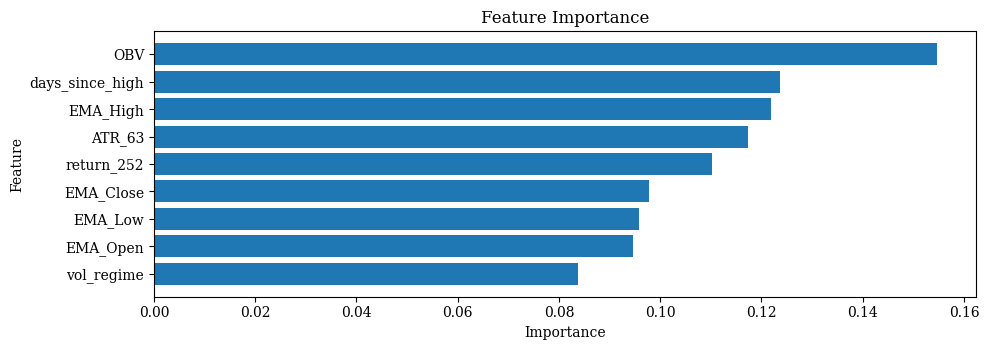

In [ ]:
plt.figure(figsize=(10, 0.4 * len(feat_imp)))

plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

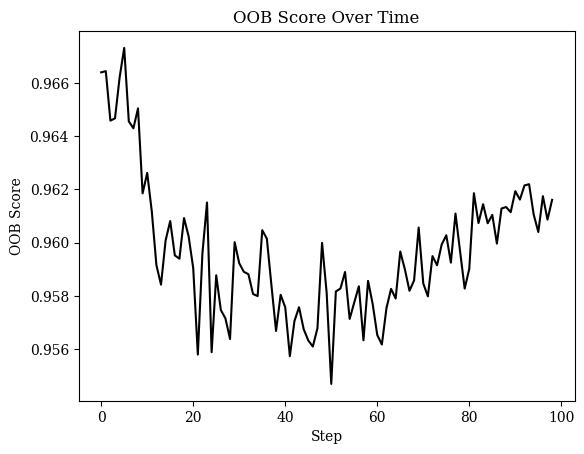

In [ ]:
plt.plot(oob_scores, 'k')
plt.title("OOB Score Over Time")
plt.xlabel("Step")
plt.ylabel("OOB Score")
plt.show()

In [ ]:
def simulate_trading(df, predictions, horizon=90,
                    initial_capital=10000,
                    trade_size=1000):

    df = df.copy()
    df = df.loc[predictions.index]
    df["Predictions"] = predictions["Predictions"]

    capital = initial_capital
    capital_history = []
    portfolio_history = []

    open_trades = []

    trade_count = 0
    wins = 0
    losses = 0

    trade_returns = []  # <-- store returns per trade

    for i in range(len(df)):
        today_price = df["Close"].iloc[i]

        # --- CLOSE trades ---
        new_open_trades = []
        for trade in open_trades:
            if i == trade["exit_idx"]:
                entry_price = trade["entry_price"]
                invest = trade["invest"]

                ret = (today_price - entry_price) / entry_price
                profit = invest * ret

                capital += invest + profit

                trade_returns.append(ret)  # <-- store return

                if profit > 0:
                    wins += 1
                else:
                    losses += 1
            else:
                new_open_trades.append(trade)

        open_trades = new_open_trades

        # --- OPEN new trade ---
        if (
            i < len(df) - horizon and
            df["Predictions"].iloc[i] == 1 and
            capital >= trade_size
        ):
            capital -= trade_size

            open_trades.append({
                "entry_idx": i,
                "entry_price": today_price,
                "exit_idx": i + horizon,
                "invest": trade_size
            })

            trade_count += 1

        # --- PORTFOLIO VALUE ---
        open_value = sum(
            trade["invest"] * (today_price / trade["entry_price"])
            for trade in open_trades
        )

        portfolio_value = capital + open_value

        capital_history.append(capital)
        portfolio_history.append(portfolio_value)

    df["Capital"] = capital_history
    df["Portfolio_Value"] = portfolio_history
    df["Profit"] = df["Portfolio_Value"] - initial_capital

    # --- FINAL RETURN % ---
    final_value = portfolio_history[-1]
    return_pct = (final_value - initial_capital) / initial_capital * 100

    # --- AVG RETURN PER TRADE (%) ---
    avg_return_per_trade = (
        (sum(trade_returns) / len(trade_returns)) * 100
        if trade_returns else 0
    )

    # Return volatility
    return_vol = ret.std()

    return df, trade_count, wins, losses, return_pct, avg_return_per_trade, return_vol



In [ ]:
results, trade_count, wins, losses, total_roi, roi_per_trade, return_vol = simulate_trading(df, predictions, horizon = 90, initial_capital=10000, trade_size = 1000)

In [ ]:
# S&P 500 returns over the same period

initial_capital = 10000
sp500["Returns"] = sp500["Close"].pct_change()
sp500["Portfolio_Value"] = (1 + sp500["Returns"]).cumprod() * initial_capital
sp500['Profit'] = sp500['Portfolio_Value'] - initial_capital

In [ ]:
# Test strategy vs always investing
def baseline(df, horizon=90,
                         initial_capital=10000,
                         trade_size=1000):

    df = df.copy()
    df = df.iloc[2500:]

    capital = initial_capital
    capital_history = []
    portfolio_history = []

    open_trades = []

    trade_count = 0
    wins = 0
    losses = 0

    trade_returns = []

    for i in range(len(df)):
        today_price = df["Close"].iloc[i]

        # --- CLOSE trades ---
        new_open_trades = []
        for trade in open_trades:
            if i == trade["exit_idx"]:
                entry_price = trade["entry_price"]
                invest = trade["invest"]

                ret = (today_price - entry_price) / entry_price
                profit = invest * ret

                capital += invest + profit
                trade_returns.append(ret)

                if profit > 0:
                    wins += 1
                else:
                    losses += 1
            else:
                new_open_trades.append(trade)

        open_trades = new_open_trades

        # --- OPEN trade EVERY DAY if possible ---
        if i < len(df) - horizon and capital >= trade_size:
            capital -= trade_size

            open_trades.append({
                "entry_idx": i,
                "entry_price": today_price,
                "exit_idx": i + horizon,
                "invest": trade_size
            })

            trade_count += 1

        # --- PORTFOLIO VALUE ---
        open_value = sum(
            trade["invest"] * (today_price / trade["entry_price"])
            for trade in open_trades
        )

        portfolio_value = capital + open_value

        capital_history.append(capital)
        portfolio_history.append(portfolio_value)

    df["Capital"] = capital_history
    df["Portfolio_Value"] = portfolio_history
    df['Profit'] = df['Portfolio_Value'] - initial_capital

    # --- FINAL RETURN ---
    final_value = portfolio_history[-1]
    return_pct = (final_value - initial_capital) / initial_capital * 100

    # --- AVG TRADE RETURN ---
    avg_trade_return = (
        (sum(trade_returns) / len(trade_returns)) * 100
        if trade_returns else 0
    )

    return df, trade_count, wins, losses, return_pct, avg_trade_return


In [ ]:
baseline_results, baseline_trade_count, baseline_wins, baseline_losses, baseline_total_roi, baseline_roi_per_trade = baseline(df, horizon = 90, initial_capital=10000, trade_size = 1000)

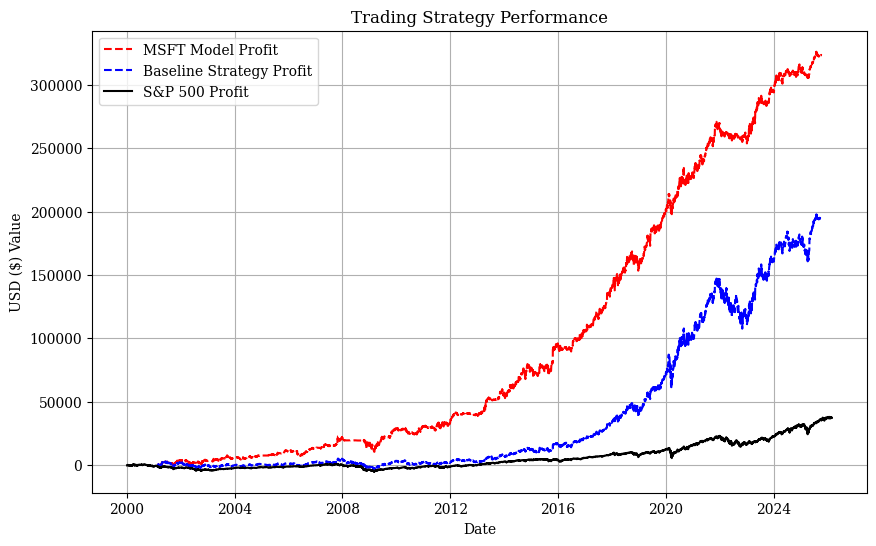

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results.index, results["Profit"], 'r--', label = 'MSFT Model Profit')
plt.plot(baseline_results.index, baseline_results["Profit"], 'b--',label = 'Baseline Strategy Profit')
plt.plot(sp500.index, sp500["Profit"], 'k-', label = 'S&P 500 Profit')
plt.legend()
plt.title("Trading Strategy Performance")
plt.xlabel("Date")
plt.ylabel("USD ($) Value")
plt.grid()
plt.show()

In [ ]:
print(f"Total Trades: {trade_count}")
print(f"Win Rate: {wins / trade_count}")
print(f"Total Return: {total_roi:.2f}%")
print(f"Average Return per Trade: {roi_per_trade:.2f}%")

Total Trades: 2815
Win Rate: 0.8603907637655417
Total Return: 3236.38%
Average Return per Trade: 11.50%


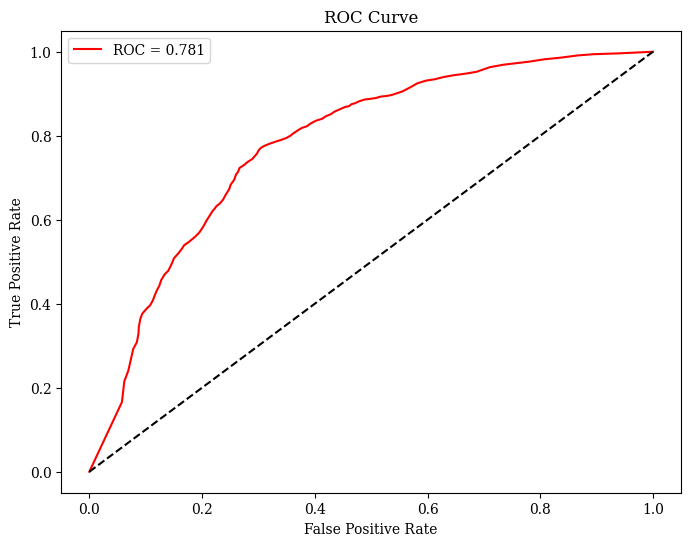

In [ ]:
y_true = predictions["Target"]
probs = predictions["Probabilities"]

fpr, tpr, thresholds = roc_curve(y_true, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, 'r', label=f"ROC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k', linestyle="--")  # y = x baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()


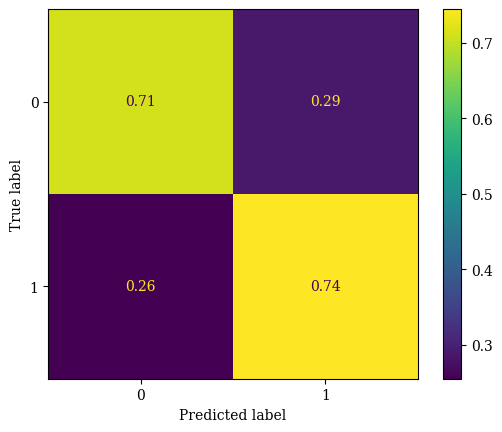

In [ ]:
cm = confusion_matrix(predictions["Target"], predictions["Predictions"], normalize = 'true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_90.classes_)
disp.plot()

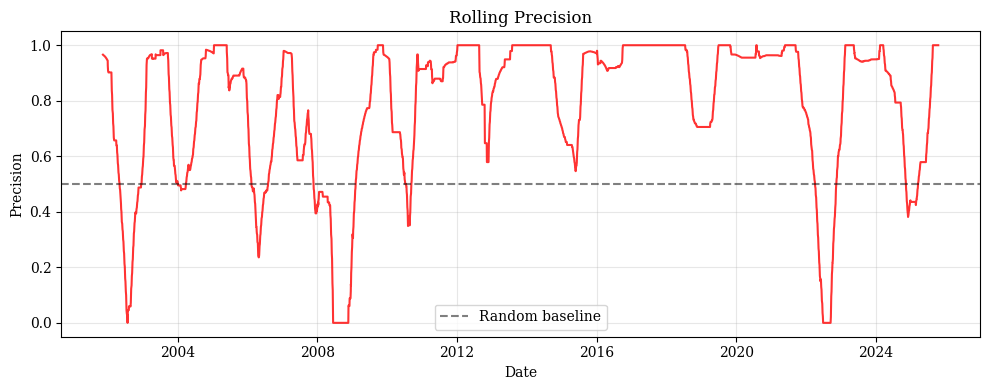

In [ ]:
def rolling_precision(predictions, window=180):
    prec = []
    dates = []
    for i in range(window, len(predictions)):
        chunk = predictions.iloc[i-window:i]
        pos_preds = chunk[chunk['Predictions'] == 1]
        if len(pos_preds) > 0:
            p = precision_score(pos_preds['Target'], pos_preds['Predictions'], zero_division=0)
        else:
            p = np.nan
        prec.append(p)
        dates.append(predictions.index[i])
    return pd.Series(prec, index=dates)

rolling_prec = rolling_precision(predictions)

plt.figure(figsize=(10, 4))
plt.plot(rolling_prec.index, rolling_prec.values, 'r', alpha=0.8)
plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Random baseline')
plt.title('Rolling Precision')
plt.xlabel('Date')
plt.ylabel('Precision')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()